# LSTM Anomaly Detection in Sensor Streams

This notebook trains an **LSTM Autoencoder** on normal sensor data from the SKAB dataset. the model learns what *normal* looks like. When something unusual happens, it can't reconstruct the signal well — that spike in error is the anomaly signal.

**Dataset:** SKAB — 35 multivariate CSV files from a real industrial water-pump testbed  
**Model:** LSTM Autoencoder (encoder compresses → decoder reconstructs)  
**Evaluation:** Precision, Recall, F1 against anomaly labels

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import LSTM, Dense, Input, RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
import kagglehub
import joblib
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Training settings
window_size = 10
epochs = 100
batch_size = 32
validation_split = 0.1
threshold_quantile = 0.97
threshold_multiplier = 1.5
train_size = 400

## 1. Data Loading & Exploration

Load all anomaly experiment files from SKAB as raw DataFrames.



In [22]:
# Download SKAB dataset
path = kagglehub.dataset_download("yuriykatser/skoltech-anomaly-benchmark-skab")

# Load only anomaly CSV files
raw_files = []
for root, _, files in os.walk(os.path.join(path, "SKAB")):
    for file in sorted(files):
        if not file.endswith(".csv"):
                continue
        if "anomaly-free" in file:
                continue

        df = pd.read_csv(
                os.path.join(root, file),
                sep=";",
                index_col="datetime",
                parse_dates=True,
            )
        raw_files.append(df)

print(f"Loaded {len(raw_files)} anomaly files")
# Quick preview of first file
display(raw_files[0].head())


Loaded 34 anomaly files


,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,changepoint
datetime,,,,,,,,,,
2020-03-01 16:28:16,0.080968,0.132892,2.078540,0.054711,88.8333,22.0874,248.524,75.0000,0.0,0.0
2020-03-01 16:28:17,0.080721,0.137438,0.983799,0.710565,88.9111,22.0892,226.593,75.9813,0.0,0.0
2020-03-01 16:28:18,0.081400,0.128858,1.666630,0.054711,88.8676,22.0930,216.814,75.0000,0.0,0.0
2020-03-01 16:28:19,0.080755,0.135728,1.090530,0.382638,88.8907,22.0862,230.363,75.0189,0.0,0.0
2020-03-01 16:28:20,0.080394,0.132174,1.199950,0.382638,88.9437,22.0903,251.789,75.9813,0.0,0.0


## 2. Preprocessing

This section handles all preprocessing steps in one place:

1. Split each raw file into train/test chronologically (`train_size=400`)
2. Build sliding windows for LSTM input (`window_size=10`)
3. Use one settings block for training and thresholding

Scaling is still applied in the training loop (fit on train, transform train/test)
to avoid data leakage and keep the pipeline straightforward.

In [23]:
def create_sequences(values, time_steps):
    """Slide a window of length time_steps across the array.
    Returns shape: (n_windows, time_steps, n_features)
    """
    n_windows = len(values) - time_steps + 1
    return np.stack([values[i:i + time_steps] for i in range(n_windows)])

def build_splits(raw_files, train_size=400):
    """Convert raw DataFrames into (X_train, X_test, y_train, y_test) tuples."""
    splits = []
    for df in raw_files:
        X = df.drop(["anomaly", "changepoint"], axis=1)
        y = df["anomaly"]
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, train_size=train_size, shuffle=False
        )
        splits.append((X_train, X_test, y_train, y_test))
    return splits


splits = build_splits(raw_files, train_size=train_size)

# check for null values across all files
null_counts = pd.concat(raw_files).isnull().sum()
print(null_counts)

print(f"Prepared {len(splits)} train/test splits")

Accelerometer1RMS      0
Accelerometer2RMS      0
Current                0
Pressure               0
Temperature            0
Thermocouple           0
Voltage                0
Volume Flow RateRMS    0
anomaly                0
changepoint            0
dtype: int64
Prepared 34 train/test splits


## 3. Model

The autoencoder has two parts:
- **Encoder:** one LSTM layer that reads the full window and outputs a single vector (the bottleneck)
- **Decoder:** `RepeatVector` copies that vector back to sequence length, then another LSTM + Dense layer reconstructs the original sensors

I use **MAE (mean absolute error)** as the loss — it's less sensitive to occasional large spikes in normal data than MSE would be, so the model doesn't overfit to avoiding those rare large errors.

ReLU activation is used instead of tanh to reduce vanishing gradients  


In [24]:
def set_seed(seed=0):
    """set random seeds for reproducibility."""
    np.random.seed(seed)
    tf.random.set_seed(seed)


def build_lstm_autoencoder(n_steps, n_features):
    """LSTM Autoencoder.
    Input shape:  (n_steps, n_features)
    Output shape: (n_steps, n_features)  — same as input
    Loss measures how well it reconstructs the input window."""
    set_seed(0)
    inputs  = Input(shape=(n_steps, n_features))

    # Encoder: compress the window into a single vector
    encoded = LSTM(100, activation="relu")(inputs)
    # bottleneck layer  
    encoded = Dense(50, activation="relu")(encoded)  
    # Decoder: expand that vector back to a sequence, then reconstruct each timestep
    decoded = RepeatVector(n_steps)(encoded)
    decoded = LSTM(100, activation="relu", return_sequences=True)(decoded)
    decoded = TimeDistributed(Dense(n_features))(decoded)

    model = Model(inputs, decoded)
    model.compile(optimizer="adam", loss="mae", metrics=["mse"])
    return model


def reconstruction_error(x_true, x_pred):
    """MAE across both time and features."""
    return np.mean(np.abs(x_true - x_pred), axis=(1, 2))


def compute_threshold(errors, q=0.97, mult=1.5):
    """threshold: quantile(errors, q) * mult."""
    errors = np.asarray(errors)
    return float(np.quantile(errors, q) * mult)



## 4. Training

Training a separate model for each of the 34 files. This is intentional —  
each file represents a different experiment with slightly different normal operating conditions,  
so a per-file model fits that baseline more precisely than one global model would.



In [25]:
predicted_outlier = []   # binary anomaly predictions per file
true_outlier      = []   # ground-truth anomaly labels per file
history_logs      = []   # training curves, saved for plotting

os.makedirs("models", exist_ok=True)

for i,(X_train, X_test, y_train, y_test) in enumerate(splits):

    # normalize
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # build sequences
    X_train_seq = create_sequences(X_train_scaled, window_size)

    # train
    model = build_lstm_autoencoder(window_size, X_train_seq.shape[2])
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True, verbose=0)

    history = model.fit(
        X_train_seq, X_train_seq,
        validation_split=validation_split,
        epochs=epochs,
        batch_size=batch_size,
        shuffle=False,
        callbacks=[early_stopping],
        verbose=0,
    )
    history_logs.append(history.history)

    # threshold from train reconstruction errors
    train_pred = model.predict(X_train_seq, verbose=0)
    train_err  = reconstruction_error(X_train_seq, train_pred)
    ucl = compute_threshold(train_err, q=threshold_quantile, mult=threshold_multiplier)

    # predict on test
    X_test_seq = create_sequences(X_test_scaled, window_size)
    test_pred  = model.predict(X_test_seq, verbose=0)
    test_err   = reconstruction_error(X_test_seq, test_pred)

    # flag windows where error exceeds the threshold
    prediction = pd.Series(
        (test_err > ucl).astype(int),
        index=X_test.index[window_size - 1:],
    ).fillna(0)
    predicted_outlier.append(prediction)
    true_outlier.append(y_test.iloc[window_size - 1:])
    # save model, scaler, and threshold for this split
    model.save(f"models/model_{i}.keras")
    joblib.dump(scaler, f"models/scaler_{i}.pkl")
    np.save(f"models/ucl_{i}.npy", ucl)

print(f"Training complete — {len(splits)} models trained")

Training complete — 34 models trained


### Model architecture

In [26]:
test = build_lstm_autoencoder(window_size, X_train_seq.shape[2])
test.summary()

Model: "functional_104"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_104 (InputLayer)    │ (None, 10, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_208 (LSTM)                 │ (None, 100)            │        43,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_208 (Dense)               │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_104               │ (None, 10, 50)         │             0 │
│ (RepeatVector)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_209 (LSTM)                 │ (None, 10, 100)        │        60,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_104            │ (None, 10, 8)          │           808 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,858 (429.13 KB)

 Trainable params: 109,858 (429.13 KB)

 Non-trainable params: 0 (0.00 B)

### Training curves



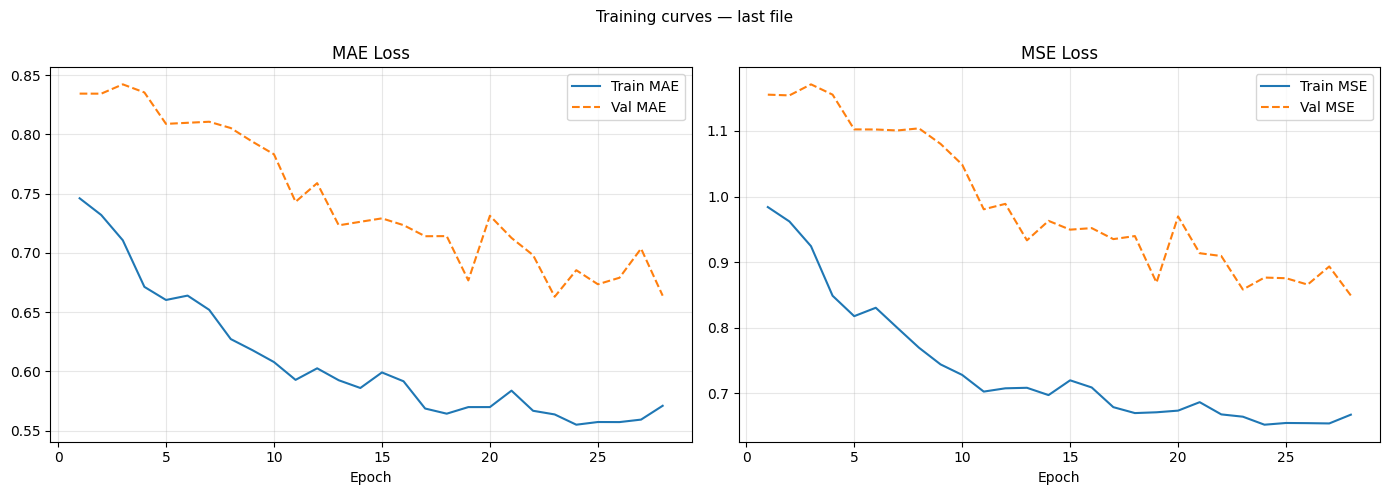

In [27]:
# Show loss curves from the last file 
last = history_logs[-1]
epochs_range = range(1, len(last["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, last["loss"],     label="Train MAE")
axes[0].plot(epochs_range, last["val_loss"], label="Val MAE", linestyle="--")
axes[0].set_title("MAE Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, last["mse"],     label="Train MSE")
axes[1].plot(epochs_range, last["val_mse"], label="Val MSE", linestyle="--")
axes[1].set_title("MSE Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Training curves — last file", fontsize=11)
plt.tight_layout()
plt.show()



## 5. Evaluation

Predictions from all 34 files are concatenated and compared against the ground-truth labels.

- **Precision**  of everything we flagged, how much was actually anomalous
- **Recall**  of all real anomalies, how many did we catch
- **F1**  the harmonic mean of the two; the main metric for imbalanced datasets like this one



Precision : 0.69
Recall    : 0.74
F1        : 0.72

Confusion Matrix:
[[6278 4334]
 [3322 9619]]


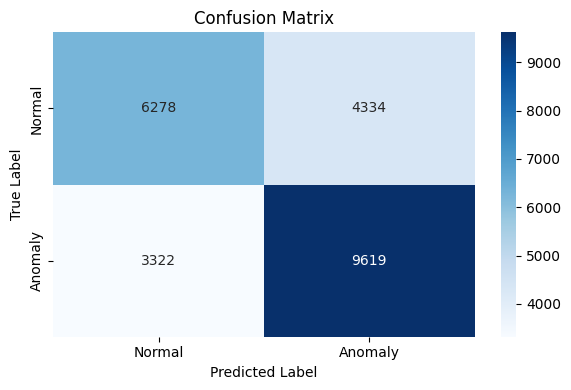

In [ ]:

# merge files per outputs into one vector for global evaluation
all_true = np.concatenate([s.values for s in true_outlier])
all_pred = np.concatenate([s.values for s in predicted_outlier])

# main classification metrics
precision = precision_score(all_true, all_pred, zero_division=0)
recall = recall_score(all_true, all_pred, zero_division=0)
f1 = f1_score(all_true, all_pred, zero_division=0)
cm = confusion_matrix(all_true, all_pred)

print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")
print(f"F1        : {f1:.2f}")
print("\nConfusion Matrix:")
print(cm)

# heatmap view of the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["Normal", "Anomaly"],
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## 6. Demo

Picks one experiment file by index, loads its trained model, scaler, and threshold,
runs inference, and prints the detection results.

Change `DEMO_FILE_ID` to any number between 0 and 33 to test a different file.
If the file has ground-truth labels the cell also prints Precision, Recall, and F1
so the result can be compared against the full evaluation above.

In [29]:
DEMO_FILE_ID = 11 # which model to load (0–33)
DEMO_CSV      = raw_files[DEMO_FILE_ID] # uses the already-loaded DataFrame

# load saved artifacts
demo_model  = tf.keras.models.load_model(f"models/model_{DEMO_FILE_ID}.keras")
demo_scaler = joblib.load(f"models/scaler_{DEMO_FILE_ID}.pkl")
demo_UCL    = float(np.load(f"models/ucl_{DEMO_FILE_ID}.npy"))

# preprocess
sensor_cols  = [c for c in DEMO_CSV.columns if c not in ["anomaly", "changepoint"]]
scaled       = demo_scaler.transform(DEMO_CSV[sensor_cols])
X_seq        = create_sequences(scaled, window_size)

# predict
errors       = reconstruction_error(X_seq, demo_model.predict(X_seq, verbose=0))
flags        = (errors > demo_UCL).astype(int)

# results
y_true = DEMO_CSV["anomaly"].iloc[window_size - 1:].values
print(f"File index : {DEMO_FILE_ID}")
print(f"Threshold  : {demo_UCL:.4f}")
print(f"Windows    : {len(errors)}")
print(f"Flagged    : {flags.sum()} ({flags.mean():.1%})")
print(f"Precision  : {precision_score(y_true, flags, zero_division=0):.2f}")
print(f"Recall     : {recall_score(y_true, flags, zero_division=0):.2f}")
print(f"F1         : {f1_score(y_true, flags, zero_division=0):.2f}")


File index : 11
Threshold  : 0.9350
Windows    : 1070
Flagged    : 550 (51.4%)
Precision  : 0.62
Recall     : 1.00
F1         : 0.76
